<img src="jupyter.png">

Для данной фигуры соотношение длин диагоналей: $ \frac{2a}{2b} = \frac{2380}{1644} \approx 1.448$

$a = 1.448 \cdot b$

Пусть центр элипса находится в точке $(x, y) = (740, 550)$

In [ ]:
import math as mh
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import random
import plotly.express as px
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import Image

from ipywidgets import IntProgress
from IPython.display import display

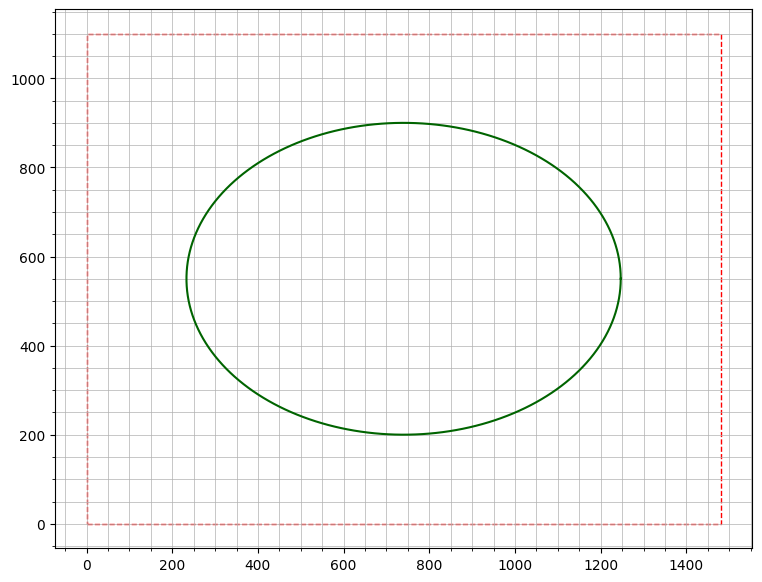

In [ ]:
x_0 = 740
y_0 = 550

b = 350
a = 1.448 * b
l_x = x_0 * 2
l_y = y_0 * 2

t = np.linspace(0, 2*mh.pi, 200)
fig = plt.figure(figsize=(9, 7))
ax = fig.subplots(1,1)
ax.grid(True, which='both', linewidth=0.5)
ax.add_patch(patches.Rectangle((0, 0), l_x, l_y, linewidth=1, edgecolor='red', facecolor='none', linestyle='--'))
ax.plot(x_0+a*np.cos(t) , y_0+b*np.sin(t), color="darkgreen")
ax.minorticks_on()

### Модель

In [ ]:
class Model():
  def __init__(self, points:int, iters:int):
    self.points = points
    self.iters = iters
    self.x_0 = 740
    self.y_0 = 550
    self.b = 350
    self.a = 1.448 * self.b
    self.l_x = x_0 * 2
    self.l_y = y_0 * 2

    #Normal distribution
    self.mu = 0.5
    self.sigma = 0.2

    #Particle parameters
    self.a1 = 0.5
    self.a2 = 0.8
    self.point_step = 10.5


    self.x_points = np.empty((self.iters, self.points), dtype='float')
    self.y_points = np.empty((self.iters, self.points), dtype='float')
    self.points_size = np.zeros(1)
    self.randomize_points()

  def randomize_points(self):
    self.x_points[0] = np.random.uniform(low=0, high=self.l_x, size=self.points)
    self.y_points[0] = np.random.uniform(low=0, high=self.l_y, size=self.points)
    self.points_size = np.random.normal(self.mu, self.sigma, size=self.points)

  def plot_borders(self, ax):
    t = np.linspace(0, 2*mh.pi, 100)
    ax.add_patch(patches.Rectangle((0, 0), self.l_x, self.l_y, linewidth=2, edgecolor='red', facecolor='none', linestyle='--'))
    ax.plot(self.x_0+self.a*np.cos(t) , self.y_0+self.b*np.sin(t), linewidth=2, color="darkgreen")
    return ax

  def plot_poits(self, iter_num, ax):
    colors = np.empty(self.points, dtype='<U10')
    colors[self.points_size < self.a1] = 'hotpink'
    colors[((self.points_size >= self.a1) & (self.points_size < self.a2))] = 'darkviolet'
    colors[self.points_size >= self.a2] = 'indigo'
    sizes = np.empty(self.points, dtype='int')
    sizes[self.points_size < self.a1] = 6
    sizes[((self.points_size >= self.a1) & (self.points_size < self.a2))] = 11
    sizes[self.points_size >= self.a2] = 20
    ax.scatter(self.x_points[iter_num], self.y_points[iter_num], c=colors, s=sizes)
    return ax

  def plot_grid(self, ax):
    ax.grid(True, which='both', linewidth=0.5)
    ax.minorticks_on()
    return ax

  def is_inside_ellipse(self, x, y):
    # result = np.empty(len(x), dtype='bool')
    # result = False
    # result[((x-self.x_0)**2/(self.a)**2 + (y-self.y_0)**2/(self.b)**2) <= 1]
    # return result
    if ((x-self.x_0)**2/(self.a)**2 + (y-self.y_0)**2/(self.b)**2 <= 1):
      return True
    else:
      return False

  def is_outside_rectangle(self, x, y):
    if (x < 0 or x > self.l_x or y < 0 or y > self.l_y):
      return True
    else:
      return False

  def run(self):
    vdo_step = np.vectorize(self.do_step)
    progressBar = IntProgress(min=0, max=self.iters, description='Modeling:', style={'bar_color': 'darkorchid'}, readout=True) # instantiate the bar
    display(progressBar)
    for iter in range(1, self.iters):
      self.x_points[iter],self.y_points[iter] = vdo_step(self.x_points[iter-1], self.y_points[iter-1], self.points_size)
      progressBar.value += 1

  def run_without_bar(self):
    vdo_step = np.vectorize(self.do_step)
    for iter in range(1, self.iters):
      self.x_points[iter],self.y_points[iter] = vdo_step(self.x_points[iter-1], self.y_points[iter-1], self.points_size)

  def get_next_step_value(self, x, y):
    point_angle = 2*mh.pi * np.random.rand()
    x_new = x + self.point_step * np.cos(point_angle)
    y_new = y + self.point_step * np.sin(point_angle)
    return x_new, y_new

  def do_step(self, x, y, size):
    while(True):
      x_new, y_new = self.get_next_step_value(x, y)
      if (self.is_outside_rectangle(x_new, y_new)):
        continue;
      before = self.is_inside_ellipse(x, y)
      after = self.is_inside_ellipse(x_new, y_new)
      if (size >= self.a1 and size < self.a2):
        if (before == True and after == False):
          continue
      elif (size >= self.a2):
        if before != after:
          continue
      return x_new, y_new




### Начальное распределение точек

20000 точек

3000 итераций броуновского движения на каждую точку

<Axes: >

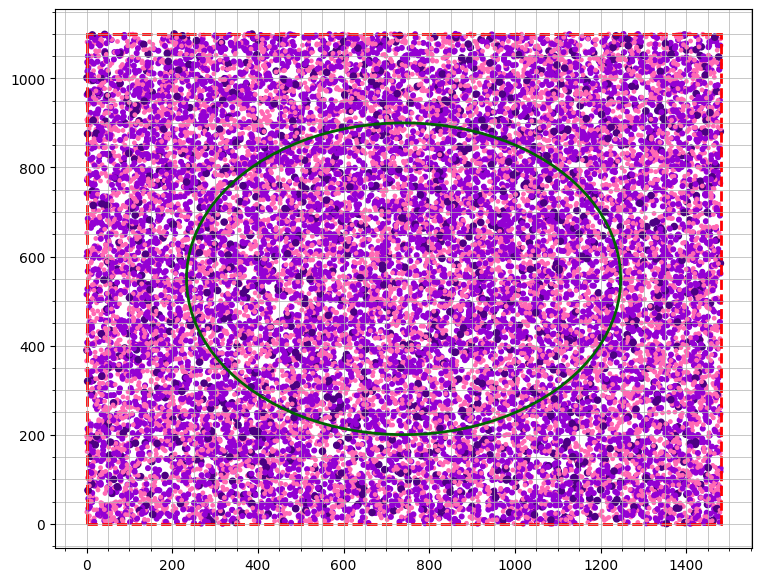

In [ ]:
model = Model(20000, 3000)
fig = plt.figure(figsize=(9, 7))
ax = fig.subplots(1,1)
model.plot_poits(0, ax)
model.plot_borders(ax)
model.plot_grid(ax)

### Запуск модели

In [ ]:
model.run()

IntProgress(value=0, description='Modeling:', max=3000, style=ProgressStyle(bar_color='darkorchid'))

#### Получившееся распределение

<Axes: >

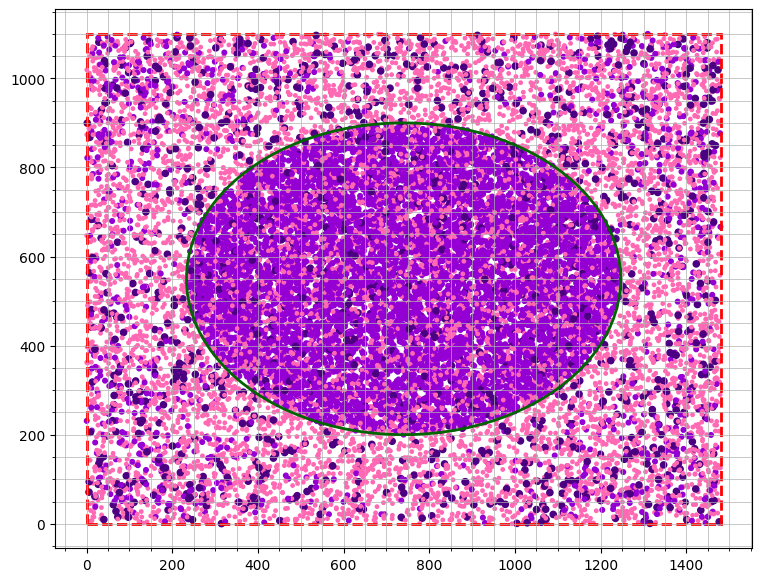

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.subplots(1,1)
model.plot_poits(model.iters - 1, ax)
model.plot_borders(ax)
model.plot_grid(ax)

#### Траектории движения частиц

В следующем примере выбираются, каждый раз случайно, по две траектории для каждого типа размеров точек.

In [ ]:
small_points = [x for x in range(model.points) if model.points_size[x] < model.a1]
middle_points = [x for x in range(model.points) if model.points_size[x] >= model.a1 and  model.points_size[x] < model.a2]
big_points = [x for x in range(model.points) if model.points_size[x] >= model.a2]

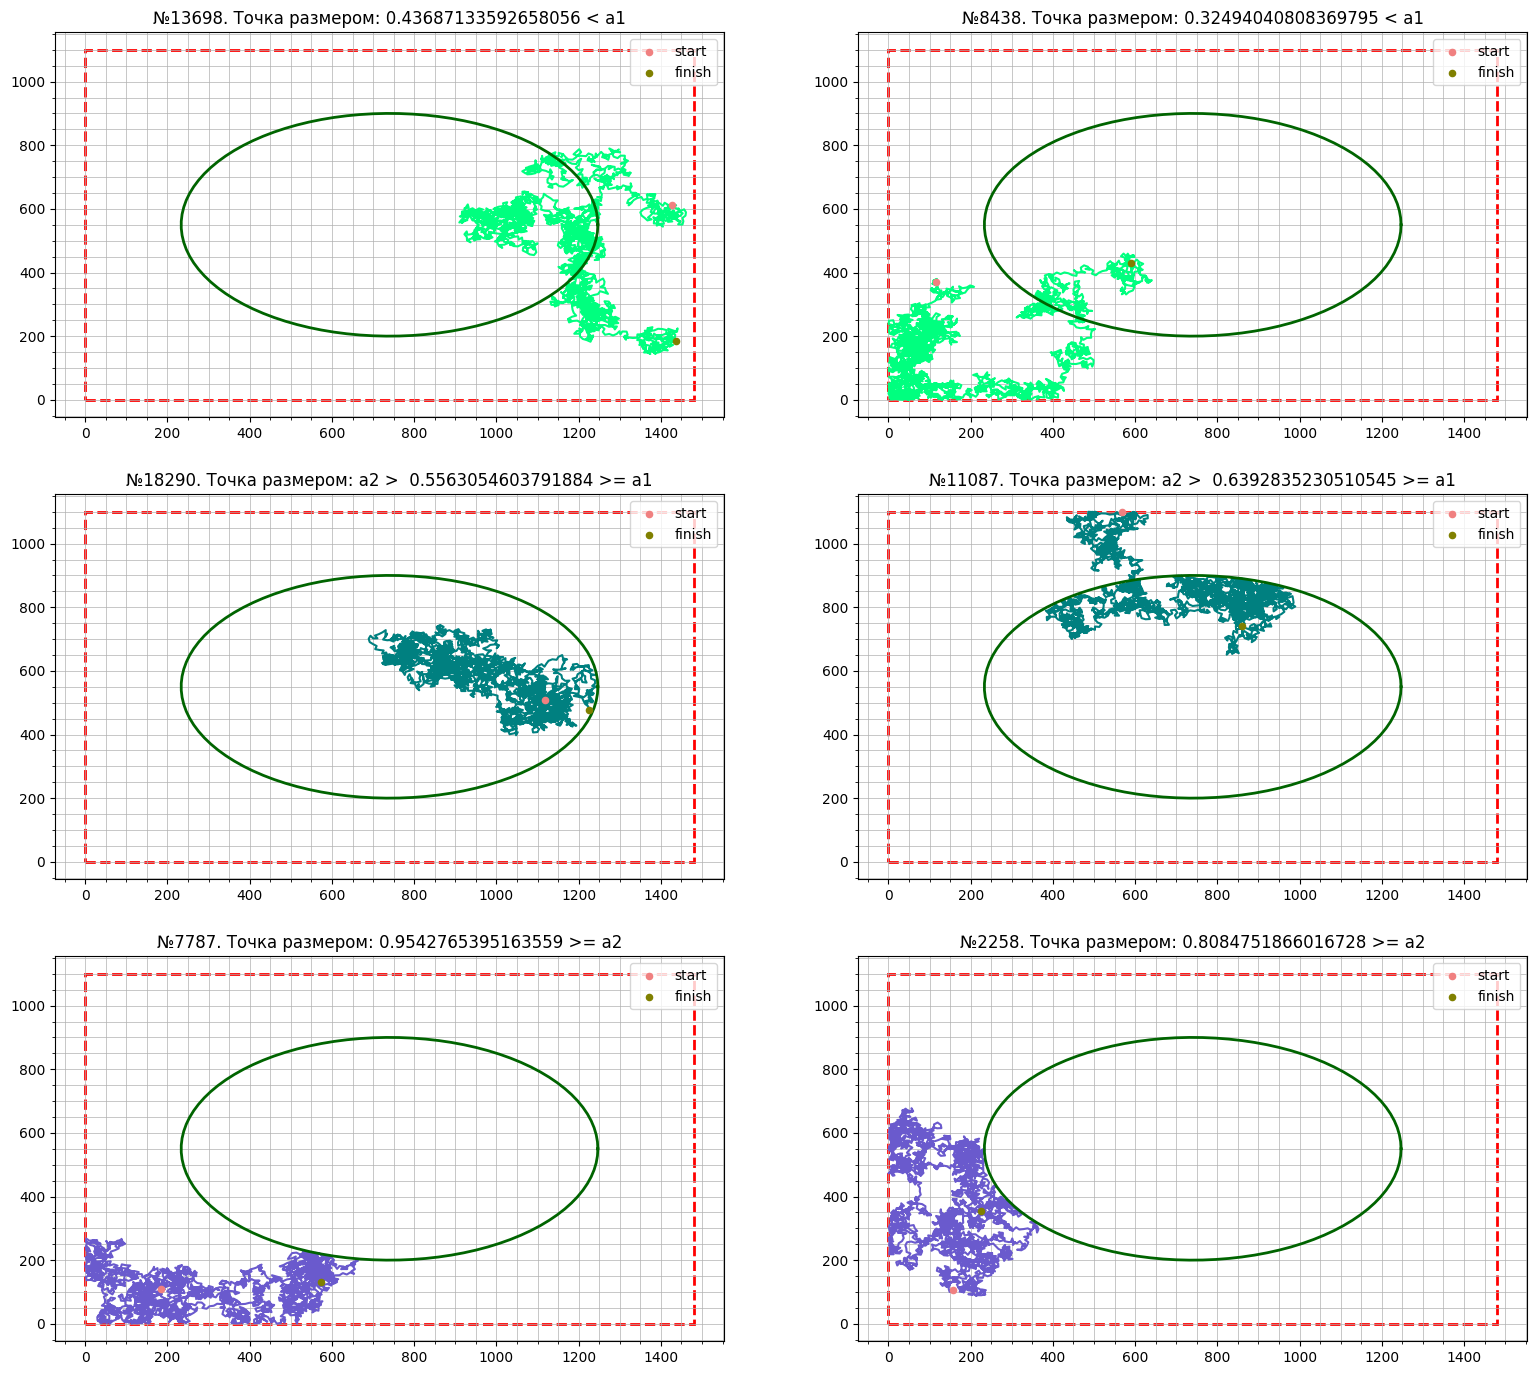

In [ ]:
fig = plt.figure(figsize=(19, 17))
h_len, v_len  = 3, 2
ax = fig.subplots(h_len, v_len)
small_numbers = [small_points[int(x)] for x in len(small_points) * np.random.rand(h_len)]
middle_numbers = [middle_points[int(x)] for x in len(middle_points) * np.random.rand(h_len)]
big_numbers = [big_points[int(x)] for x in len(big_points) * np.random.rand(h_len)]

def draw_trajectory(ax, x, y, color):
  ax.scatter(x[0], y[0], color='lightcoral', s=20, zorder=3, label="start")
  ax.scatter(x[-1], y[-1], color='olive', s=20, zorder=3, label="finish")
  ax.plot(x, y, color=color)
  ax.legend()

for i in range(0, v_len):
    draw_trajectory(ax[0][i], model.x_points[:, small_numbers[i]], model.y_points[:,small_numbers[i]], 'springgreen')
    ax[0][i].set_title(f"№{small_numbers[i]}. Точка размером: {model.points_size[small_numbers[i]]} < a1")
    model.plot_borders(ax[0][i])
    model.plot_grid(ax[0][i])

    draw_trajectory(ax[1][i], model.x_points[:, middle_numbers[i]], model.y_points[:, middle_numbers[i]], 'teal')
    ax[1][i].set_title(f"№{middle_numbers[i]}. Точка размером: a2 >  {model.points_size[middle_numbers[i]]} >= a1")
    model.plot_borders(ax[1][i])
    model.plot_grid(ax[1][i])

    draw_trajectory(ax[2][i], model.x_points[:, big_numbers[i]], model.y_points[:, big_numbers[i]], 'slateblue')
    ax[2][i].set_title(f"№{big_numbers[i]}. Точка размером: {model.points_size[big_numbers[i]]} >= a2")
    model.plot_borders(ax[2][i])
    model.plot_grid(ax[2][i])


### Расчёт площади

In [ ]:
def count_points(model, x, y):
  all = 0
  inside = 0
  for i in range(len(x)):
    if model.points_size[i] >= model.a2:
      all += 1
      if model.is_inside_ellipse(x[i],y[i]):
        inside += 1
  return inside, all

In [ ]:
experinents_count = 20000
squares = np.empty(experinents_count, dtype='float')
progressBar = IntProgress(min=0, max=experinents_count, description='Counting:', style={'bar_color': 'cyan'}, readout=True) # instantiate the bar
display(progressBar)
for i in range(experinents_count):
  new_model = Model(50000, 1)
  new_model.a2 = 0.7
  inside, all = count_points(new_model, new_model.x_points[0,:], new_model.y_points[0,:])
  coef = inside/all
  rectangle_square = model.l_x * model.l_y
  ellipse_square = rectangle_square * coef
  squares[i] = ellipse_square
  progressBar.value += 1

real_ellipse_square = model.a * model.b * mh.pi
print(f"Реальная площадь: {real_ellipse_square}")

IntProgress(value=0, description='Counting:', max=20000, style=ProgressStyle(bar_color='cyan'))

Реальная площадь: 557255.7048937575


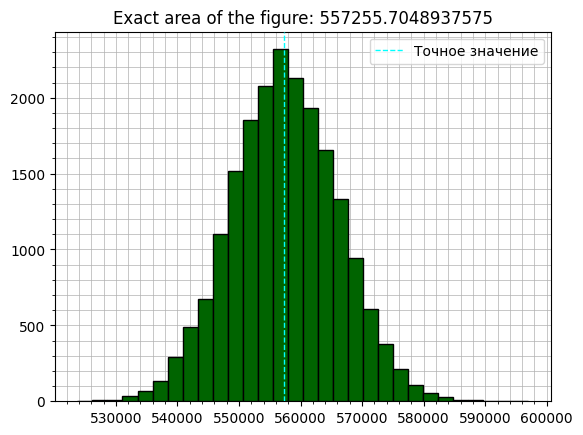

In [ ]:
plt.grid(True, which='both', linewidth=0.5, zorder=-1000)
plt.minorticks_on()
plt.hist(squares, 30, color="darkgreen", edgecolor='k', zorder = 5)
plt.axvline(real_ellipse_square, color='cyan', linestyle='dashed', linewidth=1, label="Точное значение", zorder=10)
plt.title(f"Exact area of ​​the figure: {real_ellipse_square}")
plt.legend()
plt.show()

In [ ]:
print(f"Матожидание = {np.mean(squares)}")
print(f"Дисперсия = {np.var(squares)}")
print(f"Среднеквадратичное отклонение = {np.std(squares)}")

Матожидание = 557395.4849461861
Дисперсия = 74657578.71542302
Среднеквадратичное отклонение = 8640.461718879555


### Эффективность фильтра

In [ ]:
def count_inside(model, x, y):
  inside = 0
  all = 0
  for i in range(len(x)):
    if model.points_size[i] >= model.a1 and model.points_size[i]< model.a2:
      all +=1
      if model.is_inside_ellipse(x[i],y[i]):
        inside += 1
  return inside, all

#### На каждом шаге увеличивается граница a2 и уменьшается граница a1

In [ ]:
delta = 0.02
mean = 0.5
a1 = mean - delta
a2 = mean + delta
iters = 20
model_points, model_iters = 20000, 500
step_size = 20

starts = np.empty(iters, dtype='int')
ends = np.empty(iters, dtype='int')
all = np.empty(iters, dtype='int')
progressBar = IntProgress(min=0, max=iters, description='Counting:', style={'bar_color': 'goldenrod'}, readout=True) # instantiate the bar
display(progressBar)

for i in range(iters):
  new_model = Model(model_points, model_iters)
  new_model.point_step = step_size
  new_model.a1 = a1
  new_model.a2 = a2
  starts[i], all[i]=(count_inside(new_model, new_model.x_points[0,:], new_model.y_points[0,:]))
  new_model.run_without_bar()
  ends[i], _=(count_inside(new_model, new_model.x_points[new_model.iters-1,:], new_model.y_points[new_model.iters-1,:]))
  a1 -= delta
  a2 += delta
  progressBar.value += 1

IntProgress(value=0, description='Counting:', max=20, style=ProgressStyle(bar_color='goldenrod'))

Text(0.5, 0, 'Ширина коридора между a1 и a2')

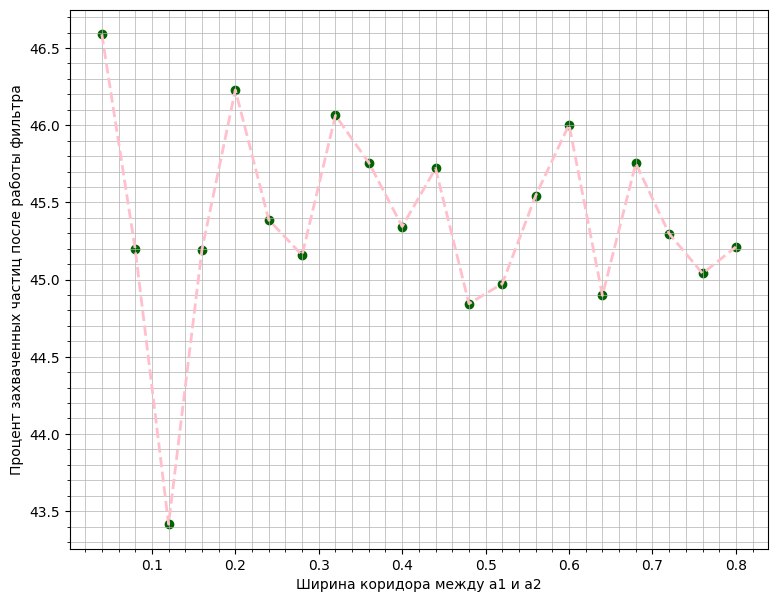

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.subplots(1,1)
ax.grid(True, which='both', linewidth=0.5)
diff = ends - starts
deltas = [x*delta*2 for x in range(1, iters+1)]
percent = (diff/all) * 100
ax.plot( deltas, percent, color="pink", linestyle='dashed', linewidth=2)
ax.scatter( deltas, percent, color="darkgreen")
ax.minorticks_on()
ax.set_ylabel("Процент захваченных частиц после работы фильтра")
ax.set_xlabel("Ширина коридора между a1 и a2")

#### а1 зафксировано, a2 увеличивается на каждой итерации

In [ ]:
delta = 0.05
mean = 0.5
a1 = 0.4
a2 = a1 + delta
iters = 30
step_size = 25

starts2 = np.empty(iters, dtype='int')
ends2 = np.empty(iters, dtype='int')
all2 = np.empty(iters, dtype='int')
progressBar = IntProgress(min=0, max=iters, description='Counting:', style={'bar_color': 'goldenrod'}, readout=True) # instantiate the bar
display(progressBar)
for i in range(iters):
  new_model = Model(10000, 500)
  new_model.point_step = step_size
  new_model.a1 = a1
  new_model.a2 = a2
  starts2[i], all2[i]=(count_inside(new_model, new_model.x_points[0,:], new_model.y_points[0,:]))
  new_model.run_without_bar()
  ends2[i], _=(count_inside(new_model, new_model.x_points[new_model.iters-1,:], new_model.y_points[new_model.iters-1,:]))
  a2 += delta
  progressBar.value += 1

IntProgress(value=0, description='Counting:', max=30, style=ProgressStyle(bar_color='goldenrod'))

Text(0.5, 0, 'Ширина коридора между a1 и a2')

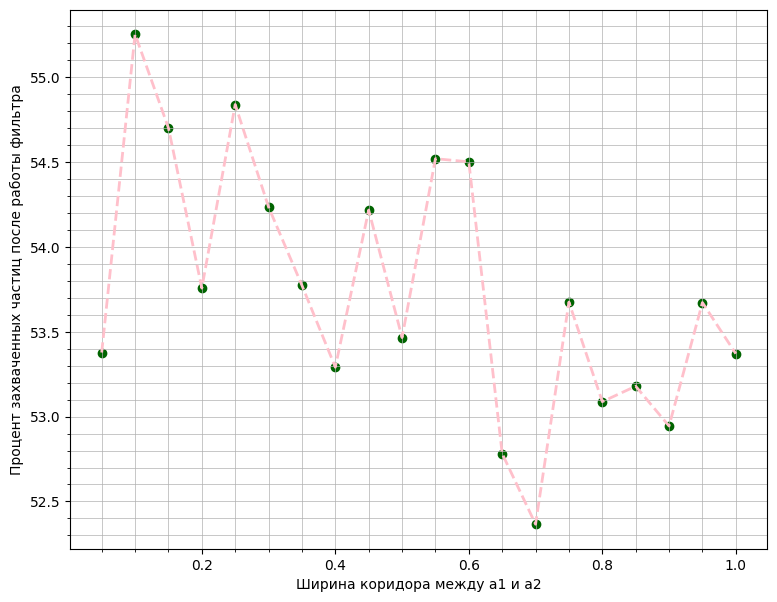

In [ ]:
diff2 = ends2 - starts2
deltas2 = [x*delta for x in range(1, 21)]
percent = ((diff2/all2) * 100)[0:20]
fig = plt.figure(figsize=(9, 7))
ax = fig.subplots(1,1)
ax.grid(True, which='both', linewidth=0.5)

ax.plot( deltas2, percent, color="pink", linestyle='dashed', linewidth=2)
ax.scatter( deltas2, percent, color="darkgreen")
ax.minorticks_on()
ax.set_ylabel("Процент захваченных частиц после работы фильтра")
ax.set_xlabel("Ширина коридора между a1 и a2")